In [1]:
import pandas as pd 
import plotly.express as px 
from dash import Dash, dcc, html, Input, Output

In [2]:
df = pd.read_csv('movies_updated.csv')
df.head(2)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,"runtime,,"
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,"146.0,"
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,"104.0,"


### Plotly

#### Exercise 1

In [3]:
df.head(5)
df.columns
df.dtypes
len(df), len(df.columns)
# we can sumarize this all by just using df.info

(4000, 15)

#### Exercise 2

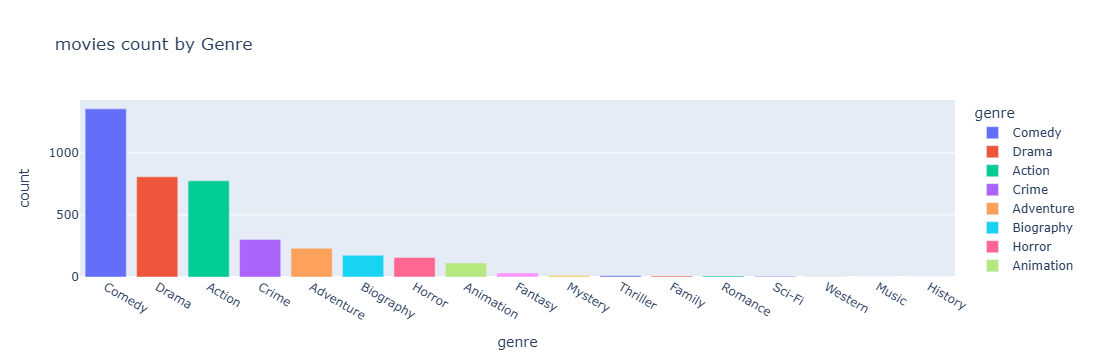

In [4]:
movie_count_by_genre = df['genre'].value_counts().reset_index()
movie_count_by_genre.columns = ['genre', 'count',]
px.bar(movie_count_by_genre, 'genre', 'count',title='movies count by Genre', color='genre')
#can simply use histogram since it automatically aggregates px.histogram(df,'genre')

#### Exercise 3

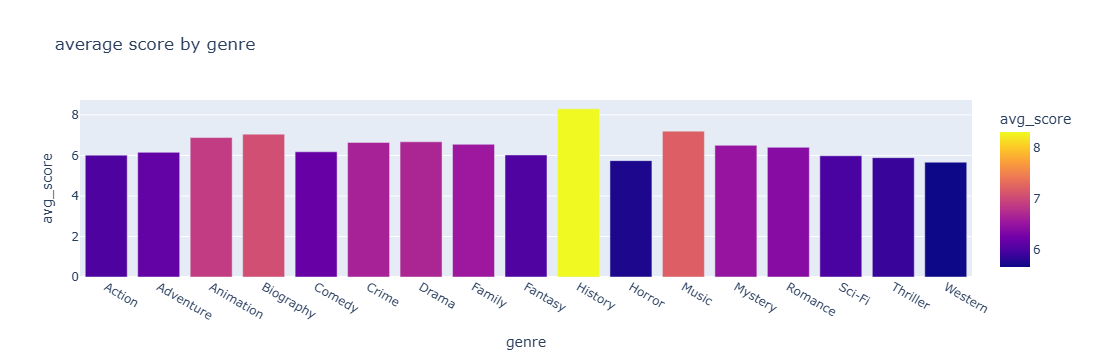

In [5]:
genre_scores = df.groupby('genre')['score'].mean().reset_index()
genre_scores.columns = ['genre', 'avg_score']
px.bar(genre_scores, 'genre', 'avg_score', title='average score by genre', color='avg_score')

#### Exercise 4

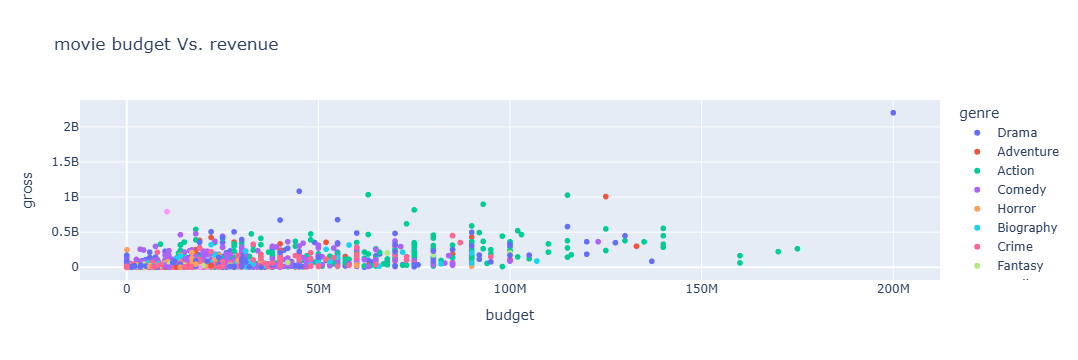

In [13]:
px.scatter(df, 'budget', 'gross', title='movie budget Vs. revenue', hover_name='name', color='genre')

#### Exercise 5

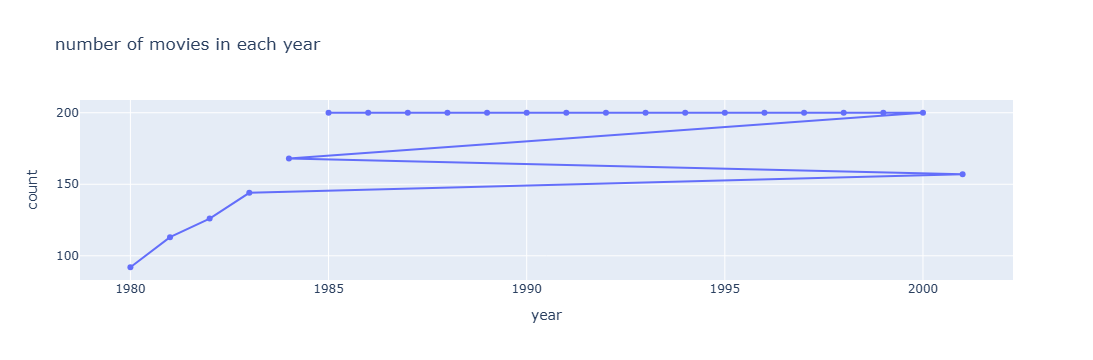

In [14]:
movie_count_by_year = df['year'].value_counts().reset_index()
movie_count_by_year.columns = ['year', 'count']
px.line(movie_count_by_year, 'year', 'count', markers='s', title='number of movies in each year')
# px.histogram(df, 'year')

#### Exercise 6

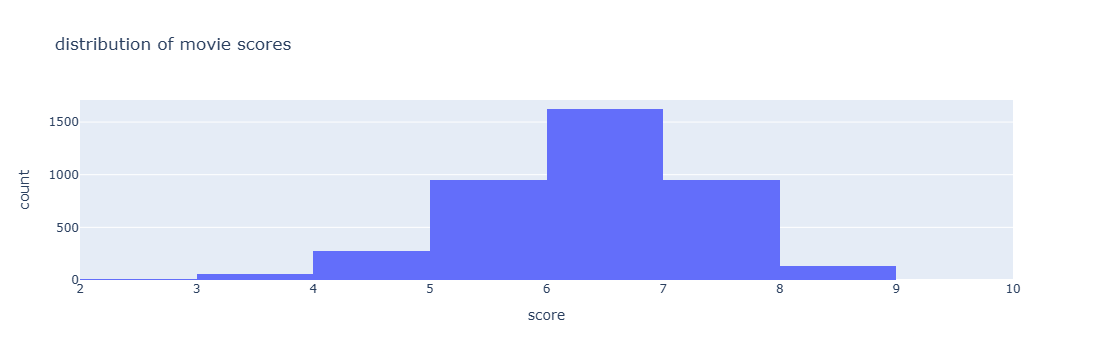

In [15]:
px.histogram(df, 'score', nbins=10, title='distribution of movie scores')

#### Exercise 7

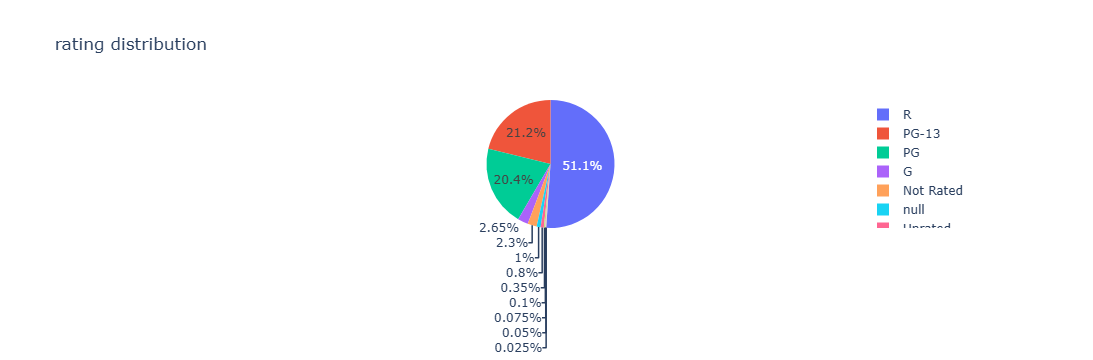

In [16]:
px.pie(df, 'rating', title='rating distribution')

#### Exercise 8

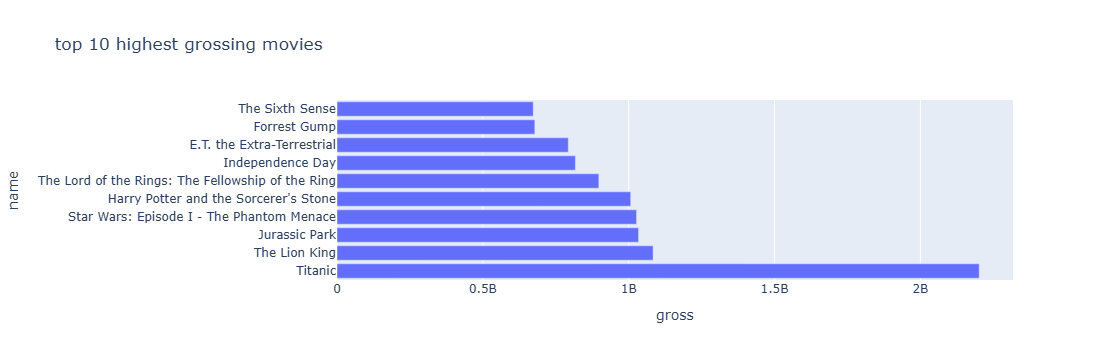

In [17]:
top_gross = df[['name', 'gross']].sort_values(by='gross', ascending=False).head(10)
px.bar(top_gross, 'gross', 'name' , orientation='h', title='top 10 highest grossing movies')

### DASH

#### Exercise: Build a Movie Analytics 

As it stands the dashboard allows users to filter movie data by genre, country, and a specific year range with dynamic barchart and a scatterplot visuals. Twick the code a bit to get certain insights

In [37]:
app = Dash(__name__)

min_year = int(df['year'].min())
max_year = int(df['year'].max())

app.layout = html.Div([
    html.H1('Movie Analytics Dashboard'),

    # Filters
    dcc.Dropdown(id="genre-dd", options=df['genre'].unique(), value="Animation", clearable=False),
    dcc.Dropdown(id="country-dd", options=df['country'].unique(), value="France", clearable=False),
    
    # Graph and labels placeholders
    html.Label("Select Year Range:"),
    dcc.RangeSlider(id="year-slider",min=min_year, max=max_year,
        value=[min_year, max_year], # Default to full range
        marks={str(y): str(y) for y in range(min_year, max_year + 1, 5)}, # Mark every 5 years
        step=1
    ),
    dcc.Graph(id="graph_rating"),
    dcc.Graph(id="graph_revenue")
    
])

@app.callback(
    Output("graph_rating", "figure"),
    Output("graph_revenue", "figure"),
    Input("genre-dd", "value"),
    Input("country-dd", "value"),
    Input("year-slider", "value")
)
def movie_chart(genre, country, years):
    # Single line to filter both conditions at once
    filtered_df = df[(df['genre'] == genre) & (df['country'] == country) & (df['year'] >= years[0]) & (df['year'] <= years[1])]
    
    agg_df = filtered_df.groupby('rating', as_index=False)['score'].mean()
    
    # Average movie score by rating
    fig1 = px.bar(agg_df, x="rating", y="score", title="Average Score by Rating")
    
    # Budget vs Gross Revenue
    fig2 = px.scatter(filtered_df, x="budget", y="gross", title="Budget vs Gross Revenue")
    
    return fig1, fig2

app.run(debug=True)